In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


train: (630000, 21)
test : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low



Categorical columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Numeric columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Target distribution:


Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: ratio, dtype: float64

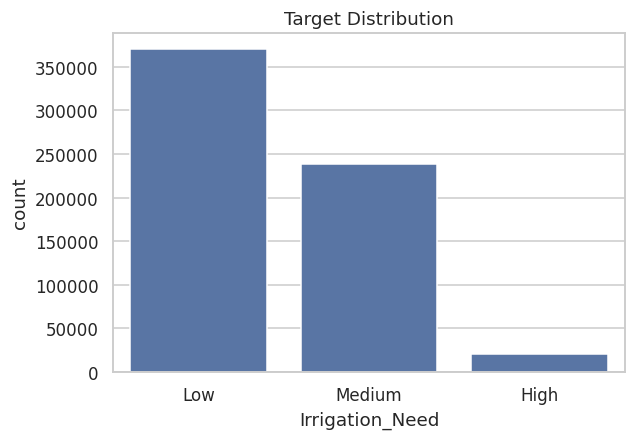


Categorical feature ranking for TE candidates:


,feature,te_candidate_score,nunique,min_count,median_count,max_count
2,Crop_Growth_Stage,0.421264,4,147502,157404.5,167689
6,Mulching_Used,0.201923,2,313547,315000.0,316453
5,Water_Source,0.025540,4,153032,156987.0,162994
4,Irrigation_Type,0.023770,4,151092,158503.5,161901
1,Crop_Type,0.019169,6,102469,104459.5,108910
3,Season,0.016153,3,205406,208033.0,216561
0,Soil_Type,0.010914,4,148566,157462.5,166509
7,Region,0.008399,5,114127,126163.0,134809


[Categorical] Soil_Type


,Soil_Type,count
0,Sandy,166509
1,Clay,158470
2,Loamy,156455
3,Silt,148566


Irrigation_Need,Soil_Type,High,Low,Medium,n_samples
0,Sandy,0.038665,0.576317,0.385018,166509
1,Clay,0.035054,0.586963,0.377983,158470
2,Loamy,0.028839,0.599265,0.371896,156455
3,Silt,0.030316,0.586817,0.382867,148566


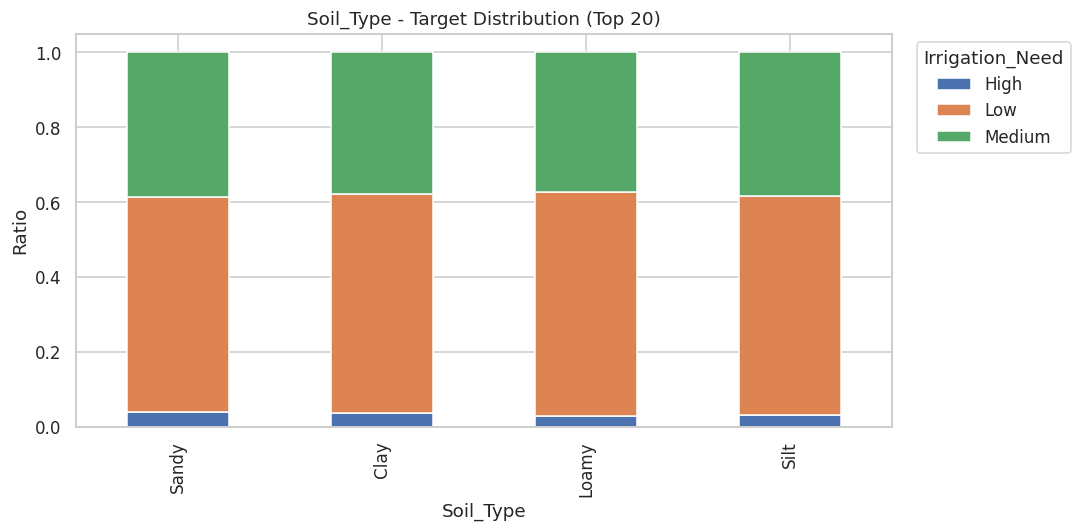

[Categorical] Crop_Type


,Crop_Type,count
0,Sugarcane,108910
1,Rice,106697
2,Cotton,104645
3,Maize,104274
4,Wheat,103005
5,Potato,102469


Irrigation_Need,Crop_Type,High,Low,Medium,n_samples
0,Sugarcane,0.039152,0.592875,0.367974,108910
1,Rice,0.023365,0.599867,0.376768,106697
2,Cotton,0.036093,0.587157,0.376750,104645
3,Maize,0.042206,0.570133,0.387661,104274
4,Wheat,0.031697,0.596456,0.371846,103005
5,Potato,0.027413,0.575901,0.396686,102469


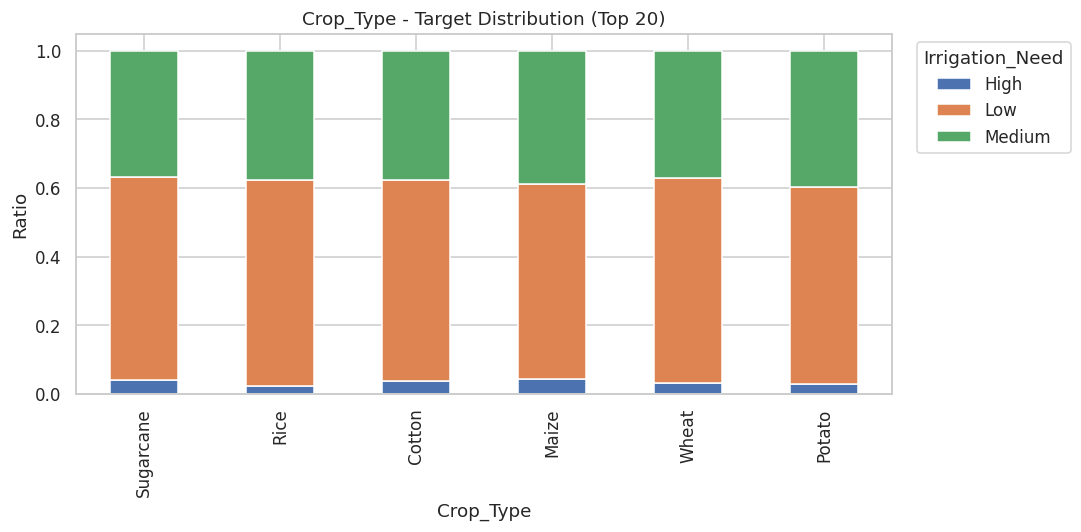

[Categorical] Crop_Growth_Stage


,Crop_Growth_Stage,count
0,Harvest,167689
1,Flowering,157563
2,Vegetative,157246
3,Sowing,147502


Irrigation_Need,Crop_Growth_Stage,High,Low,Medium,n_samples
0,Harvest,0.003202,0.847939,0.148859,167689
1,Flowering,0.064406,0.305998,0.629596,157563
2,Vegetative,0.064129,0.323792,0.612079,157246
3,Sowing,0.001627,0.871839,0.126534,147502


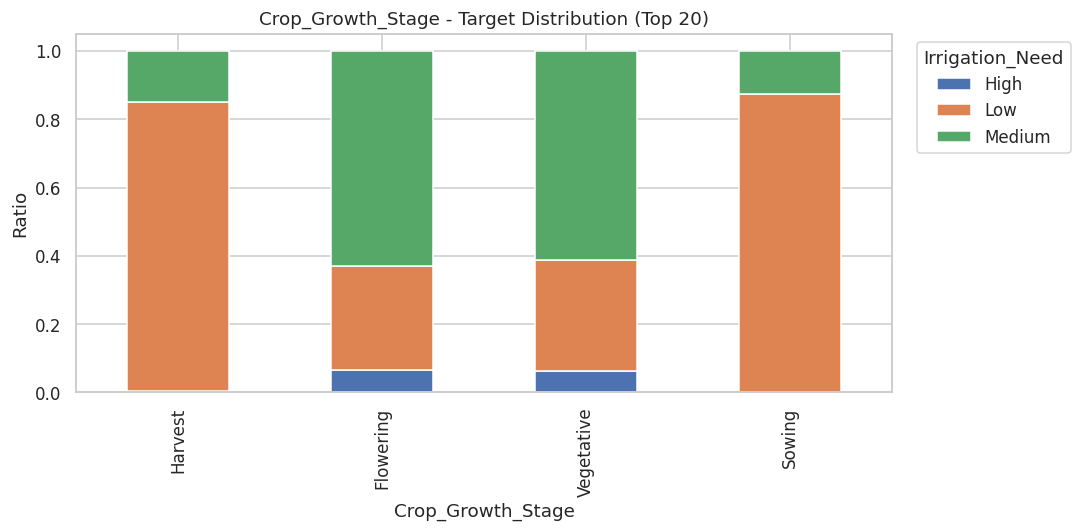

[Categorical] Season


,Season,count
0,Kharif,216561
1,Rabi,208033
2,Zaid,205406


Irrigation_Need,Season,High,Low,Medium,n_samples
0,Kharif,0.034826,0.571349,0.393824,216561
1,Rabi,0.032115,0.599770,0.368115,208033
2,Zaid,0.033037,0.591088,0.375875,205406


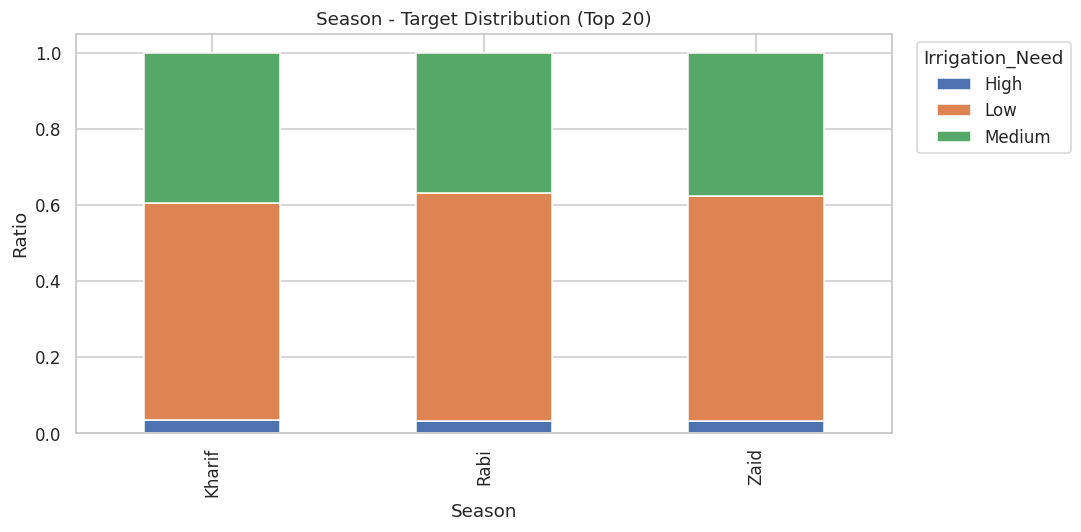

[Categorical] Irrigation_Type


,Irrigation_Type,count
0,Canal,161901
1,Sprinkler,161400
2,Rainfed,155607
3,Drip,151092


Irrigation_Need,Irrigation_Type,High,Low,Medium,n_samples
0,Canal,0.038178,0.557952,0.403870,161901
1,Sprinkler,0.034895,0.590719,0.374387,161400
2,Rainfed,0.033160,0.606676,0.360164,155607
3,Drip,0.026712,0.594598,0.378690,151092


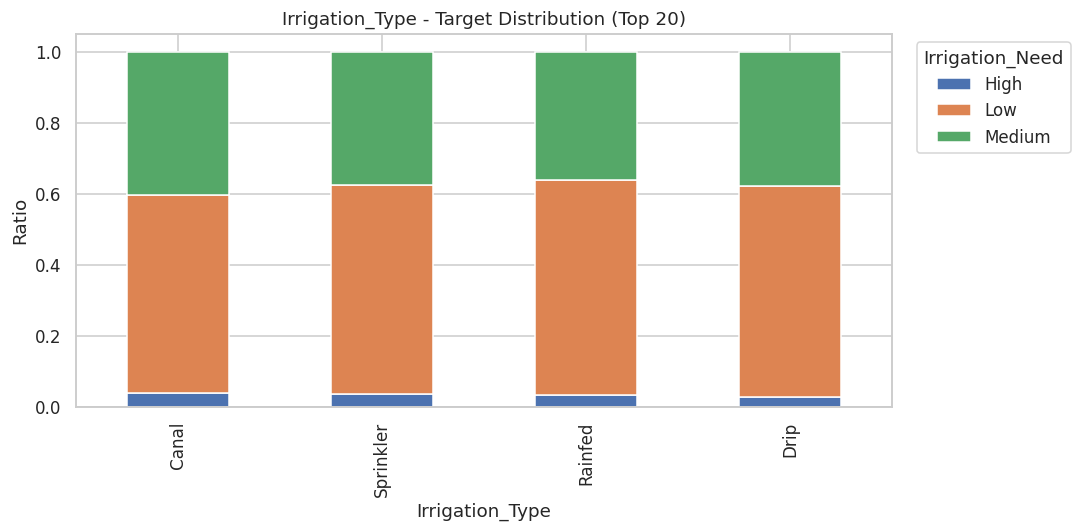

[Categorical] Water_Source


,Water_Source,count
0,Reservoir,162994
1,River,159819
2,Groundwater,154155
3,Rainwater,153032


Irrigation_Need,Water_Source,High,Low,Medium,n_samples
0,Reservoir,0.032627,0.562634,0.404739,162994
1,River,0.043437,0.583016,0.373548,159819
2,Groundwater,0.023470,0.601005,0.375525,154155
3,Rainwater,0.033529,0.603704,0.362767,153032


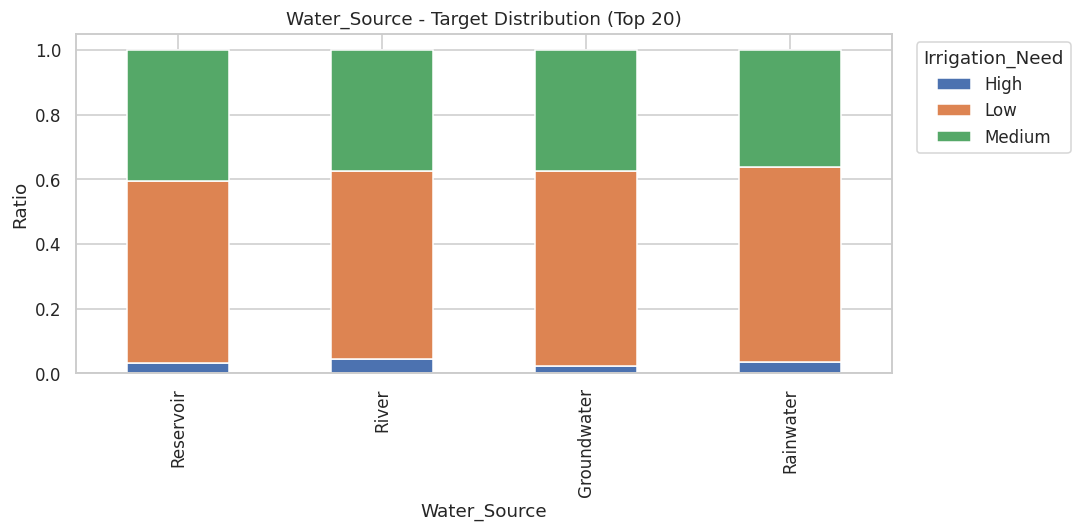

[Categorical] Mulching_Used


,Mulching_Used,count
0,No,316453
1,Yes,313547


Irrigation_Need,Mulching_Used,High,Low,Medium,n_samples
0,No,0.058527,0.445046,0.496428,316453
1,Yes,0.007935,0.730611,0.261454,313547


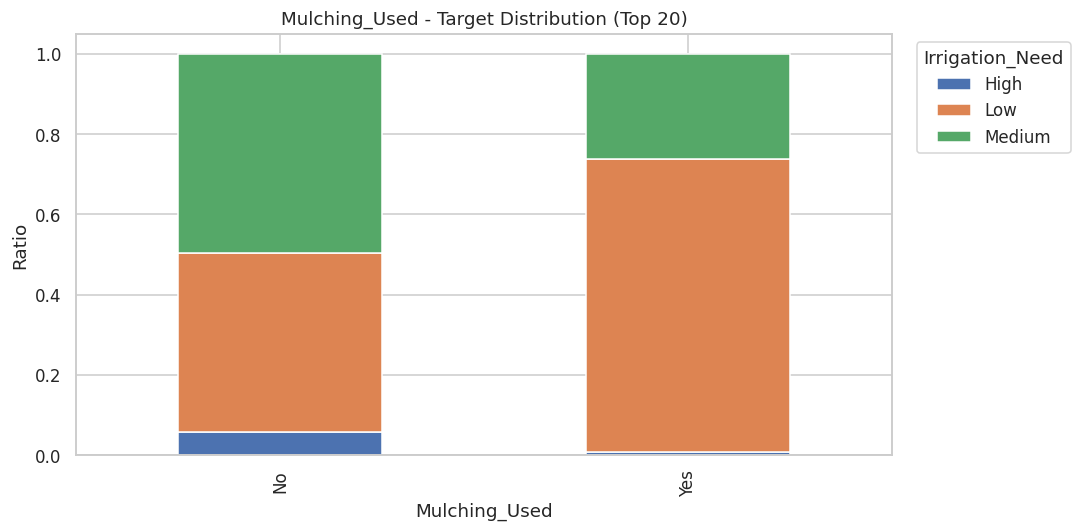

[Categorical] Region


,Region,count
0,South,134809
1,West,131189
2,East,126163
3,Central,123712
4,North,114127


Irrigation_Need,Region,High,Low,Medium,n_samples
0,South,0.034753,0.586526,0.378721,134809
1,West,0.034614,0.585766,0.379620,131189
2,East,0.028701,0.593462,0.377837,126163
3,Central,0.034354,0.593014,0.372632,123712
4,North,0.034278,0.576253,0.389470,114127


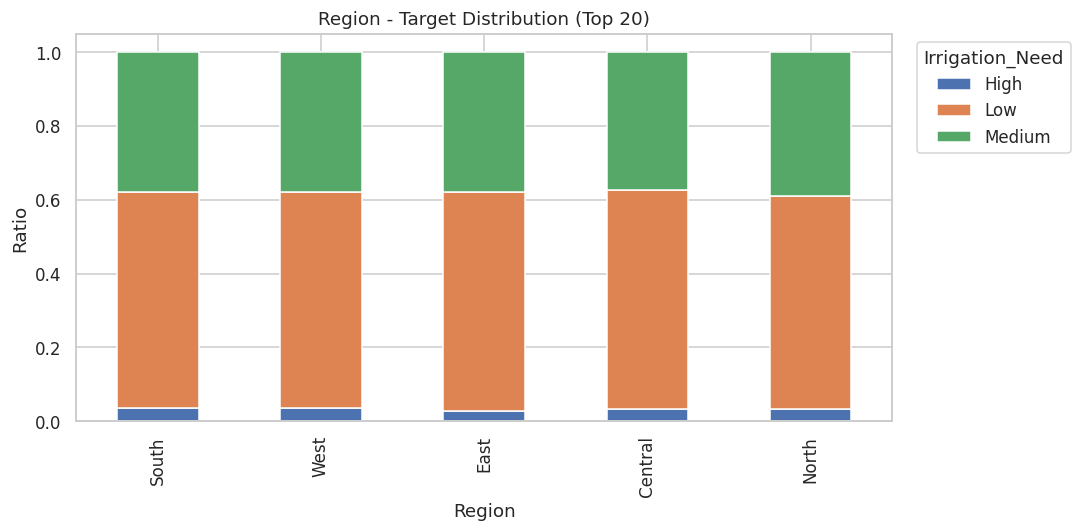


Numeric feature summary ranking:


,feature,High_mean,High_std,High_median,Low_mean,Low_std,Low_median,Medium_mean,Medium_std,Medium_median,mean_range
6,Rainfall_mm,989.156678,800.312437,764.95,1500.534313,584.804731,1498.88,1444.475028,618.449689,1463.59,511.377635
1,Soil_Moisture,17.669875,7.479613,17.09,43.305902,13.421279,44.01,29.743961,16.624592,23.89,25.636026
4,Temperature_C,34.568134,5.420716,34.91,25.347708,8.364835,24.54,28.886683,8.503269,30.66,9.220426
8,Wind_Speed_kmh,14.642639,4.118403,15.01,9.216424,5.632220,8.42,11.793668,5.388586,12.52,5.426215
10,Previous_Irrigation_mm,63.053300,32.197213,66.65,61.718330,35.548062,59.38,63.181715,32.295011,62.20,1.463385
5,Humidity,61.119576,19.242509,62.85,61.949194,19.913072,61.77,61.004887,19.413552,61.44,0.944307
9,Field_Area_hectare,7.530391,4.476655,7.49,7.447241,4.197295,7.25,7.625725,4.224577,7.56,0.178484
0,Soil_pH,6.578282,0.978948,6.59,6.487805,0.916681,6.46,6.465867,0.925763,6.40,0.112415
3,Electrical_Conductivity,1.690880,0.891465,1.65,1.731755,0.961384,1.72,1.769208,0.942780,1.76,0.078328
7,Sunlight_Hours,7.463138,2.030893,7.48,7.511125,2.000223,7.58,7.521290,1.995064,7.61,0.058152


[Numeric] Soil_pH


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,6.578282,6.487805,6.465867
std,0.978948,0.916681,0.925763
min,4.800000,4.800000,4.800000
25%,5.670000,5.700000,5.670000
50%,6.590000,6.460000,6.400000
75%,7.530000,7.250000,7.250000
max,8.200000,8.200000,8.200000


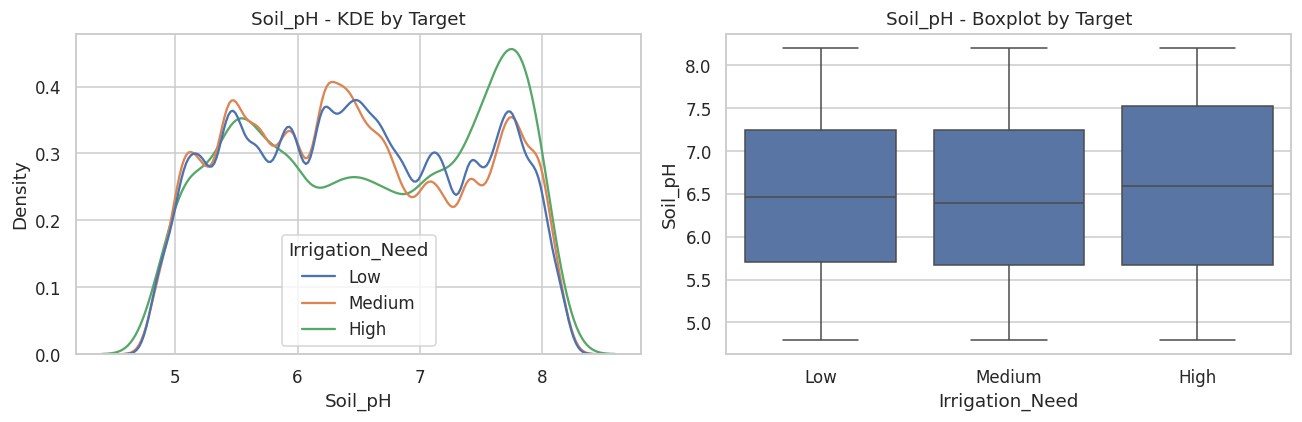

[Numeric] Soil_Moisture


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,17.669875,43.305902,29.743961
std,7.479613,13.421279,16.624592
min,8.010000,8.010000,8.000000
25%,12.140000,33.030000,16.030000
50%,17.090000,44.010000,23.890000
75%,21.670000,54.310000,43.660000
max,64.990000,64.990000,64.990000


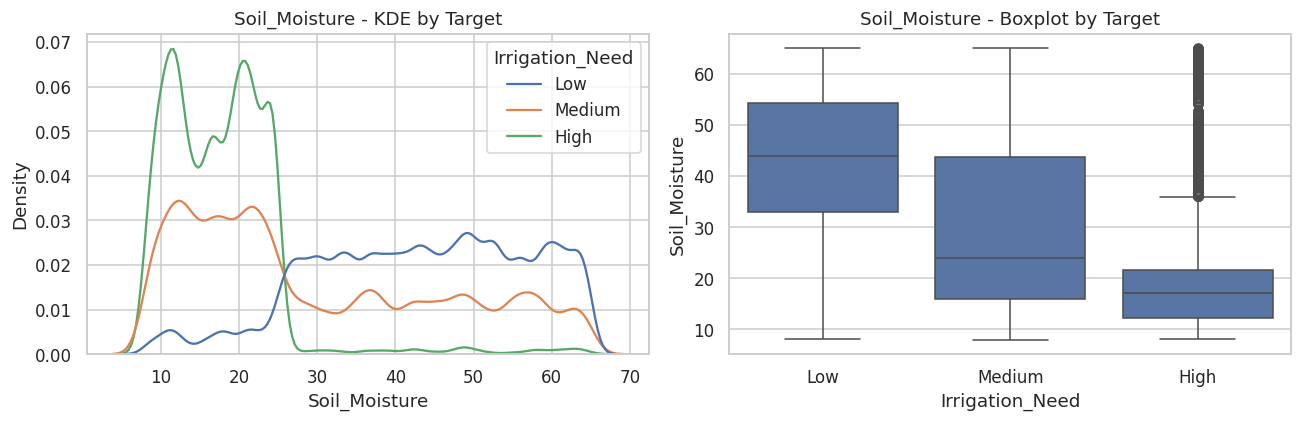

[Numeric] Organic_Carbon


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,0.924143,0.920680,0.926116
std,0.373870,0.365927,0.364882
min,0.300000,0.300000,0.300000
25%,0.580000,0.610000,0.610000
50%,0.910000,0.900000,0.930000
75%,1.250000,1.220000,1.230000
max,1.600000,1.600000,1.600000


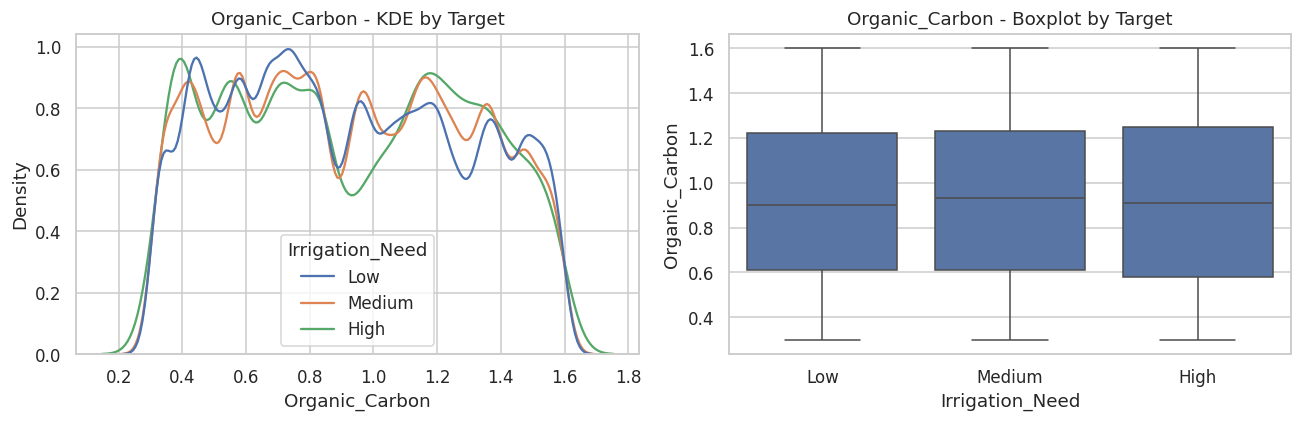

[Numeric] Electrical_Conductivity


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,1.690880,1.731755,1.769208
std,0.891465,0.961384,0.942780
min,0.100000,0.100000,0.100000
25%,0.950000,0.900000,0.970000
50%,1.650000,1.720000,1.760000
75%,2.370000,2.580000,2.590000
max,3.500000,3.500000,3.500000


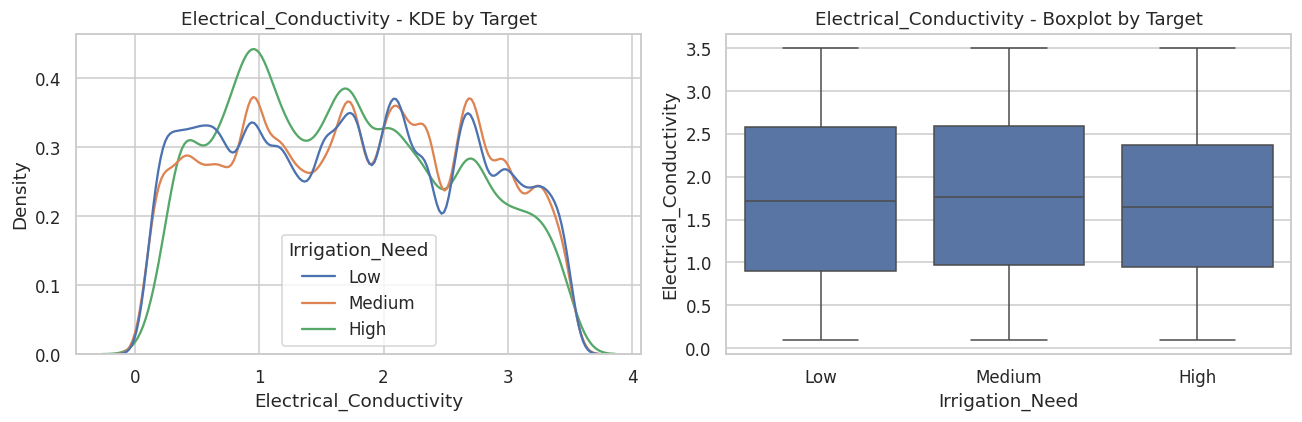

[Numeric] Temperature_C


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,34.568134,25.347708,28.886683
std,5.420716,8.364835,8.503269
min,12.020000,12.000000,12.000000
25%,31.860000,18.270000,21.530000
50%,34.910000,24.540000,30.660000
75%,38.940000,31.770000,36.180000
max,41.990000,42.000000,42.000000


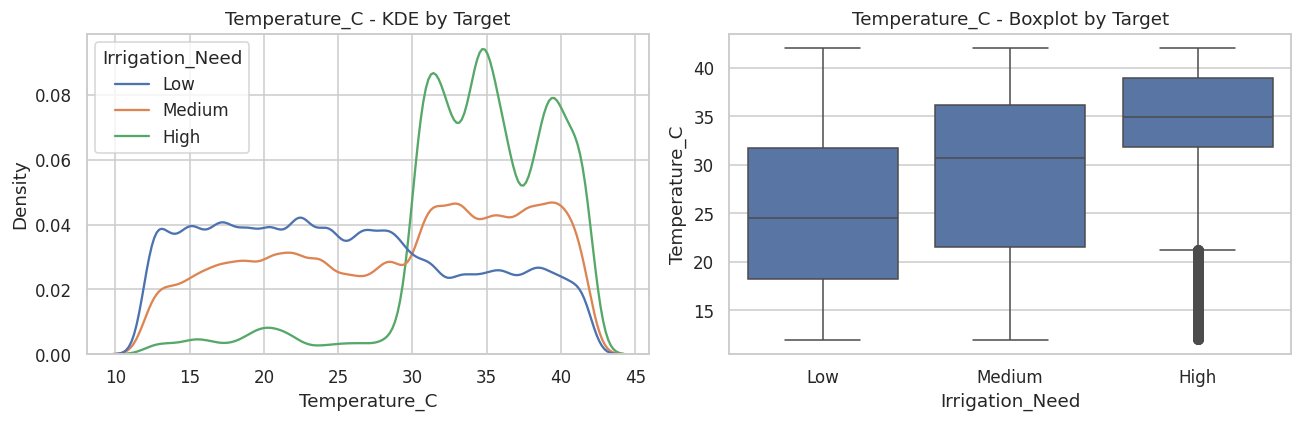

[Numeric] Humidity


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,61.119576,61.949194,61.004887
std,19.242509,19.913072,19.413552
min,25.000000,25.000000,25.000000
25%,47.550000,44.940000,46.230000
50%,62.850000,61.770000,61.440000
75%,77.160000,79.450000,78.540000
max,94.980000,94.990000,94.980000


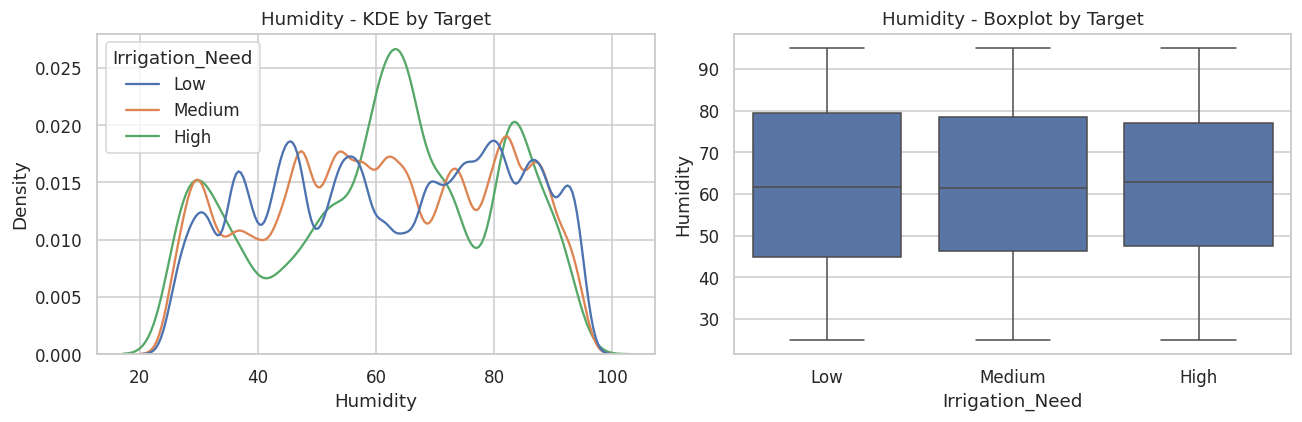

[Numeric] Rainfall_mm


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,989.156678,1500.534313,1444.475028
std,800.312437,584.804731,618.449689
min,2.180000,1.850000,0.380000
25%,209.200000,1005.000000,919.620000
50%,764.950000,1498.880000,1463.590000
75%,1705.680000,2076.860000,2023.860000
max,2499.690000,2499.690000,2499.690000


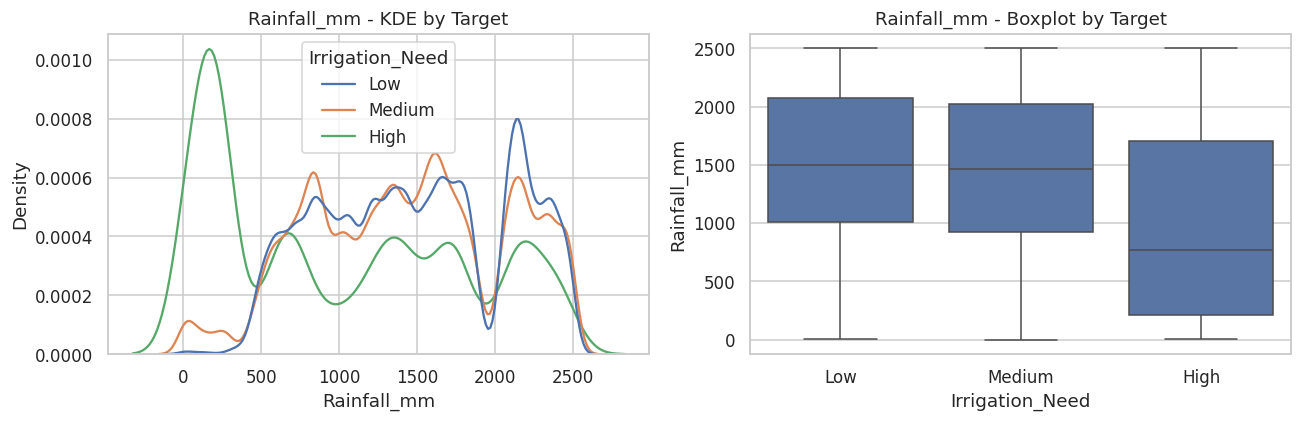

[Numeric] Sunlight_Hours


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,7.463138,7.511125,7.521290
std,2.030893,2.000223,1.995064
min,4.000000,4.000000,4.000000
25%,5.640000,5.760000,5.760000
50%,7.480000,7.580000,7.610000
75%,9.080000,9.260000,9.200000
max,11.000000,11.000000,11.000000


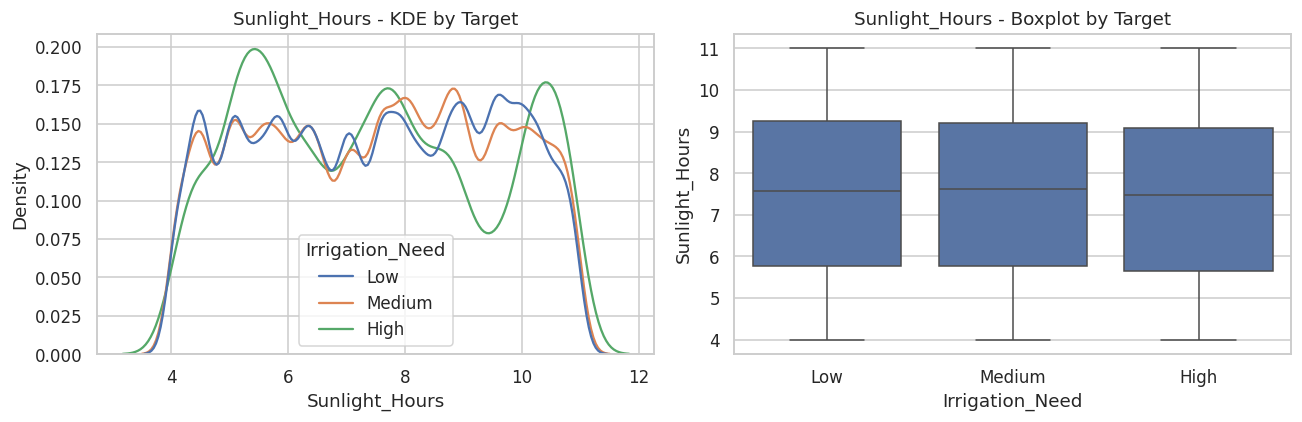

[Numeric] Wind_Speed_kmh


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,14.642639,9.216424,11.793668
std,4.118403,5.632220,5.388586
min,0.500000,0.500000,0.500000
25%,12.120000,4.320000,7.800000
50%,15.010000,8.420000,12.520000
75%,18.020000,14.290000,16.160000
max,20.000000,20.000000,20.000000


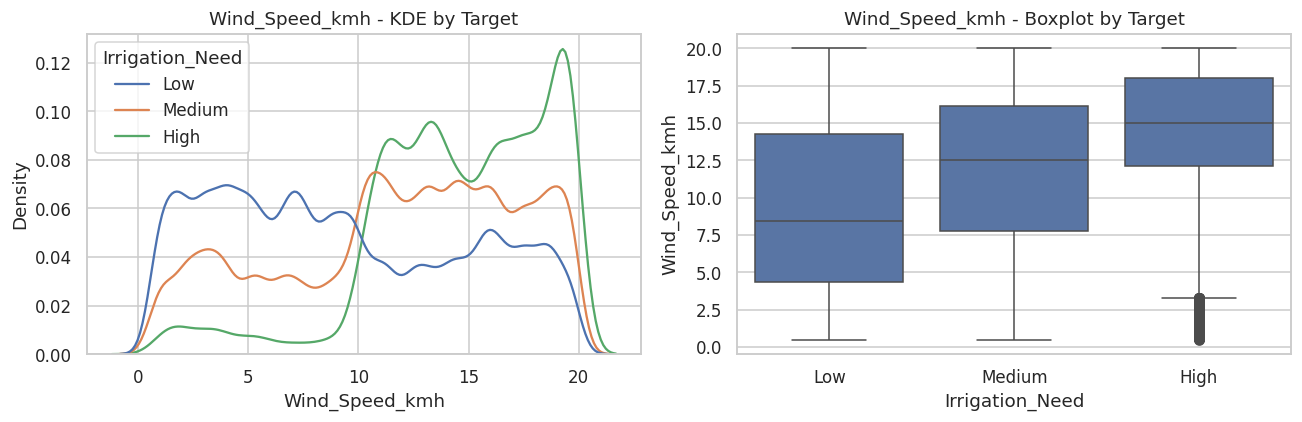

[Numeric] Field_Area_hectare


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,7.530391,7.447241,7.625725
std,4.476655,4.197295,4.224577
min,0.300000,0.310000,0.300000
25%,3.400000,3.900000,3.900000
50%,7.490000,7.250000,7.560000
75%,11.660000,11.040000,11.230000
max,15.000000,15.000000,15.000000


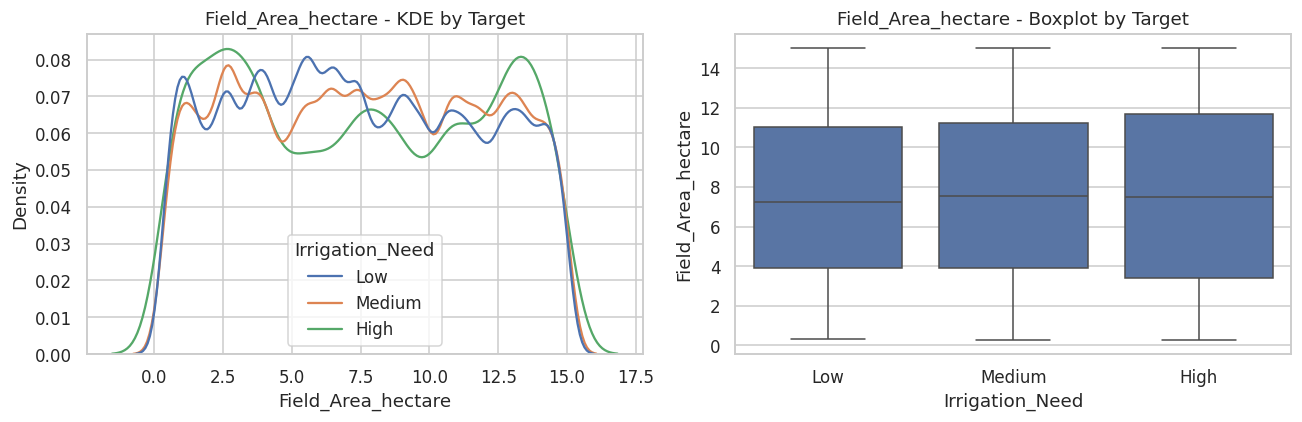

[Numeric] Previous_Irrigation_mm


Irrigation_Need,High,Low,Medium
count,21009.000000,369917.000000,239074.000000
mean,63.053300,61.718330,63.181715
std,32.197213,35.548062,32.295011
min,0.020000,0.020000,0.020000
25%,34.880000,30.950000,34.870000
50%,66.650000,59.380000,62.200000
75%,88.820000,94.900000,90.470000
max,119.880000,119.990000,119.990000


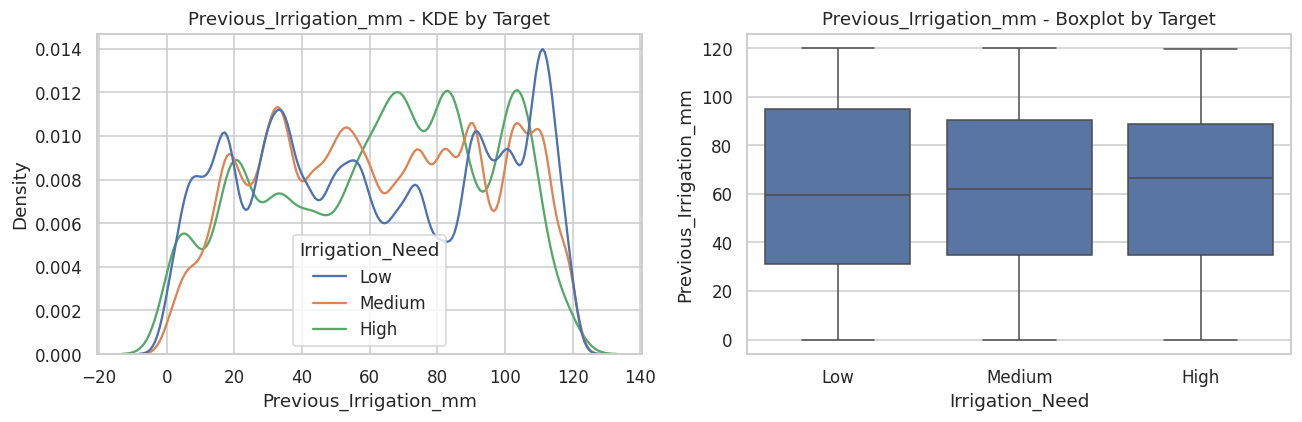


Priority categorical columns: ['Crop_Growth_Stage', 'Mulching_Used', 'Water_Source', 'Irrigation_Type']
Priority numeric columns    : ['Rainfall_mm', 'Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Previous_Irrigation_mm']
Crop_Growth_Stage x Rainfall_mm


,Crop_Growth_Stage,mean,std,median,count
0,Harvest,1487.637684,607.557905,1488.05,167689
1,Flowering,1443.698873,617.400407,1469.47,157563
2,Vegetative,1443.103662,633.121453,1459.12,157246
3,Sowing,1473.434172,590.884420,1457.54,147502


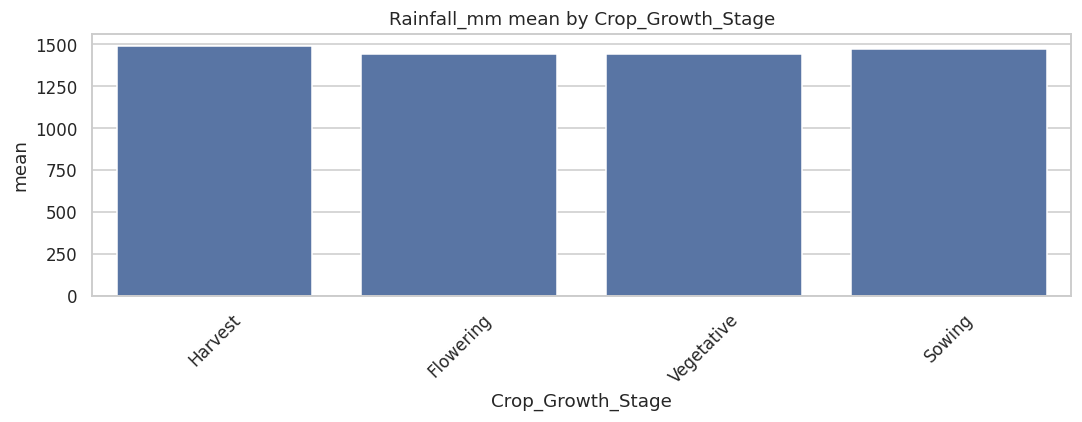

Crop_Growth_Stage x Soil_Moisture


,Crop_Growth_Stage,mean,std,median,count
0,Harvest,38.436480,15.843473,39.00,167689
1,Flowering,36.164604,17.111572,36.56,157563
2,Vegetative,34.961015,16.423195,34.44,157246
3,Sowing,39.733463,15.661221,41.45,147502


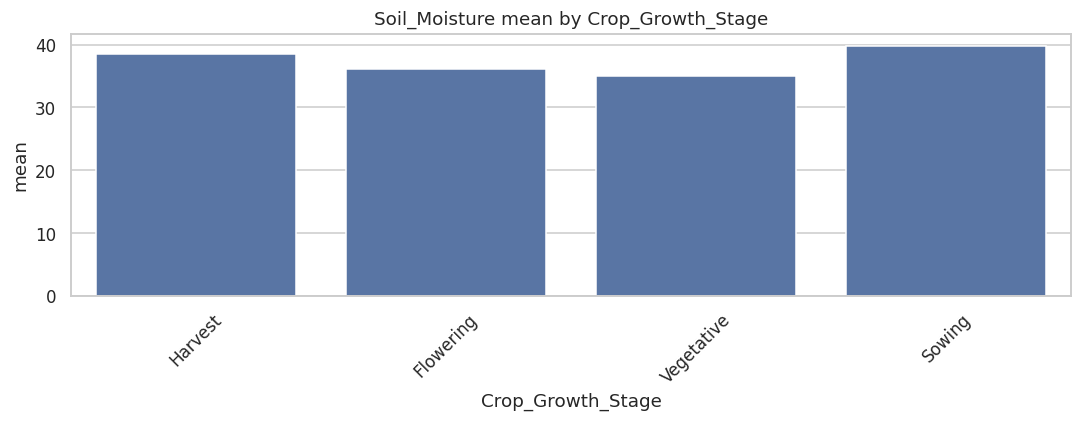

Crop_Growth_Stage x Temperature_C


,Crop_Growth_Stage,mean,std,median,count
0,Harvest,26.918761,8.737812,26.95,167689
1,Flowering,27.393203,8.689831,27.71,157563
2,Vegetative,27.014299,8.500827,26.88,157246
3,Sowing,26.649260,8.534389,26.66,147502


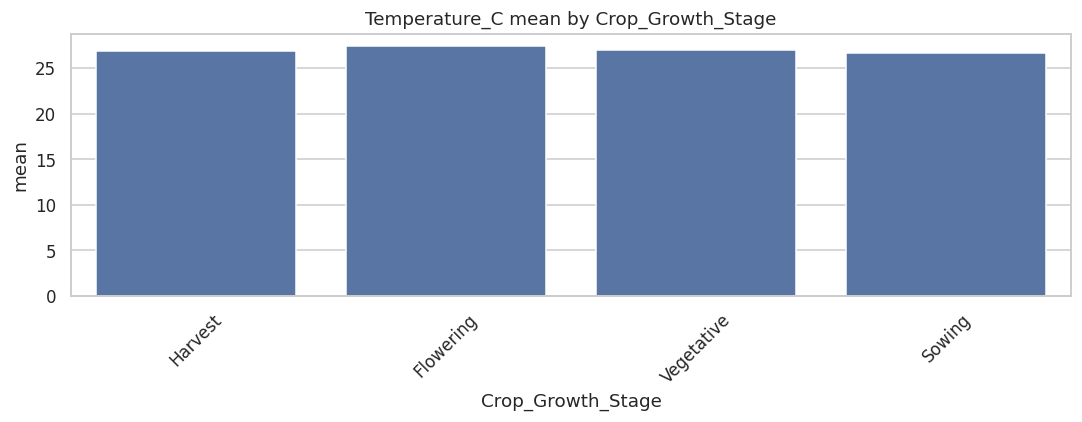

Crop_Growth_Stage x Wind_Speed_kmh


,Crop_Growth_Stage,mean,std,median,count
0,Harvest,10.190508,5.647413,9.98,167689
1,Flowering,10.527365,5.700929,10.87,157563
2,Vegetative,10.549905,5.656474,10.78,157246
3,Sowing,10.237208,5.749501,10.01,147502


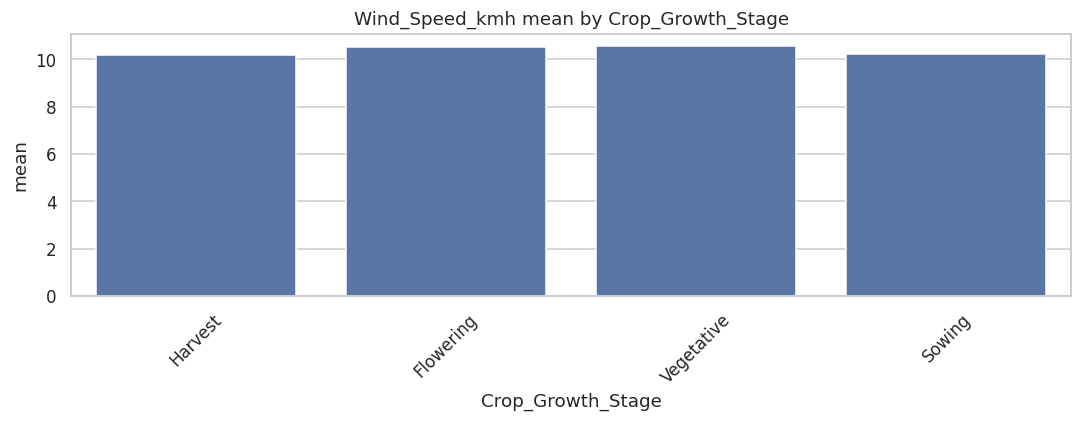

Crop_Growth_Stage x Previous_Irrigation_mm


,Crop_Growth_Stage,mean,std,median,count
0,Harvest,63.090687,35.361146,61.47,167689
1,Flowering,61.940872,33.012359,60.81,157563
2,Vegetative,62.161716,33.472124,61.23,157246
3,Sowing,62.009781,35.048388,60.81,147502


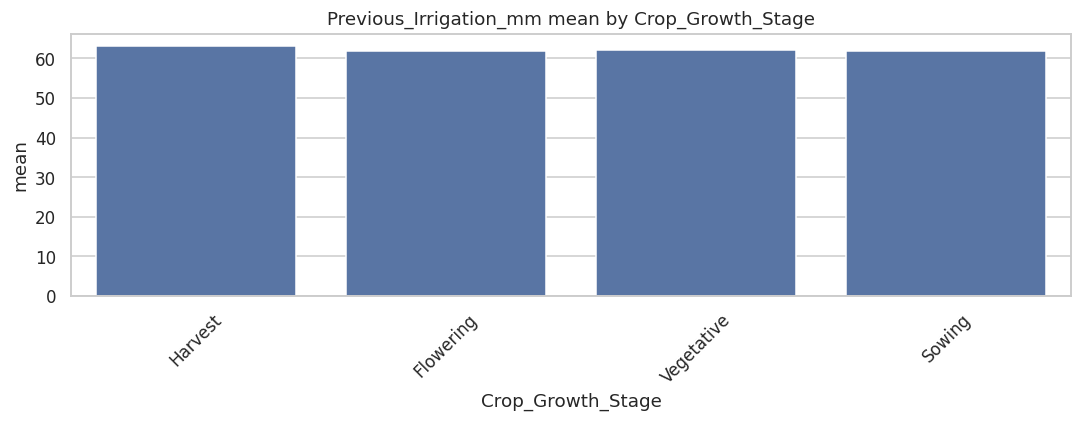

Mulching_Used x Rainfall_mm


,Mulching_Used,mean,std,median,count
0,No,1458.293976,622.211371,1468.64,316453
1,Yes,1466.157429,603.515051,1465.70,313547


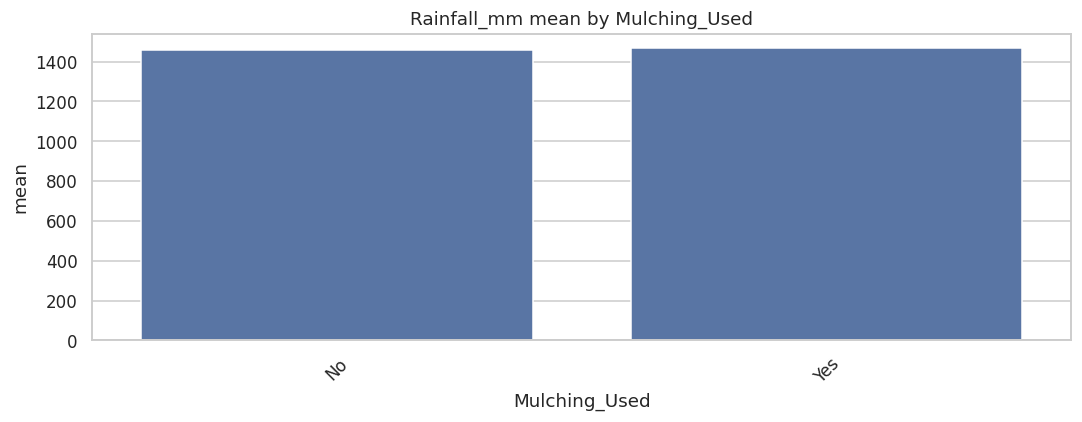

Mulching_Used x Soil_Moisture


,Mulching_Used,mean,std,median,count
0,No,36.604828,16.450356,36.73,316453
1,Yes,38.010619,16.272348,38.96,313547


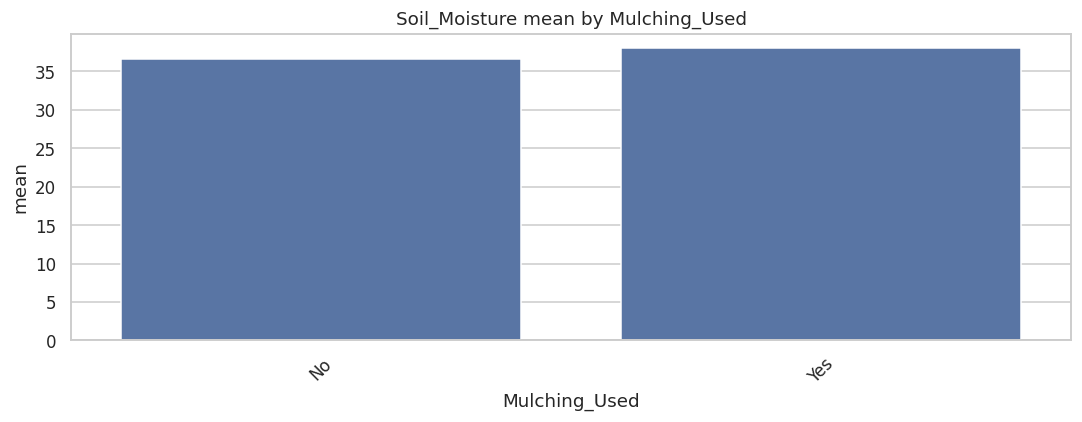

Mulching_Used x Temperature_C


,Mulching_Used,mean,std,median,count
0,No,27.046190,8.612935,27.17,316453
1,Yes,26.949698,8.634135,26.86,313547


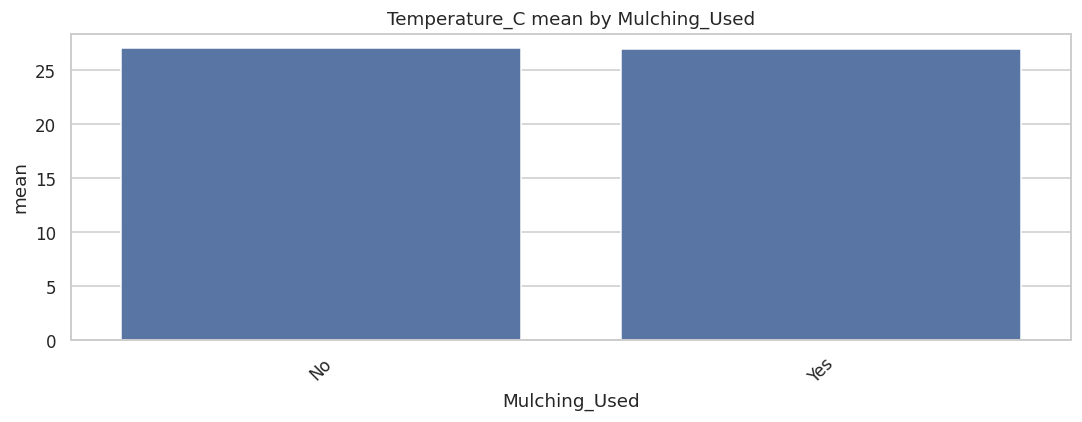

Mulching_Used x Wind_Speed_kmh


,Mulching_Used,mean,std,median,count
0,No,10.487251,5.713889,10.67,316453
1,Yes,10.262501,5.662463,10.31,313547


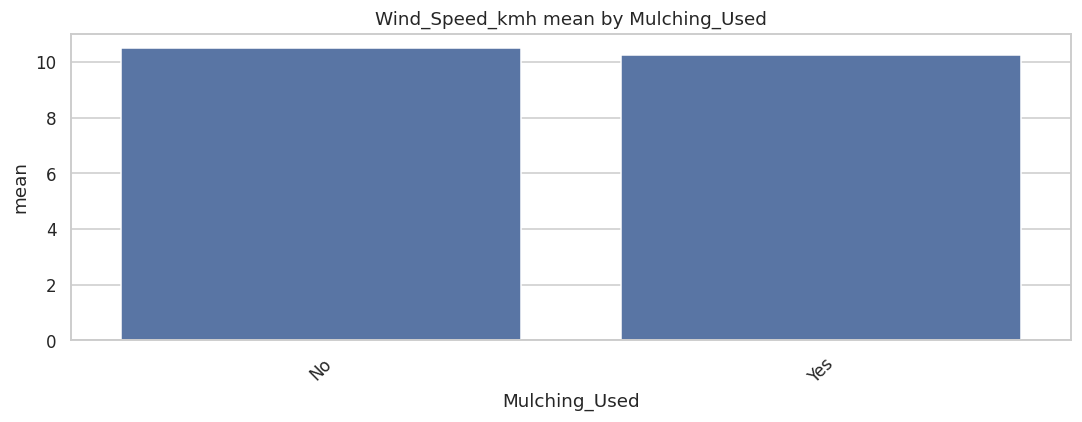

Mulching_Used x Previous_Irrigation_mm


,Mulching_Used,mean,std,median,count
0,No,62.700772,33.132183,62.05,316453
1,Yes,61.932037,35.332240,59.56,313547


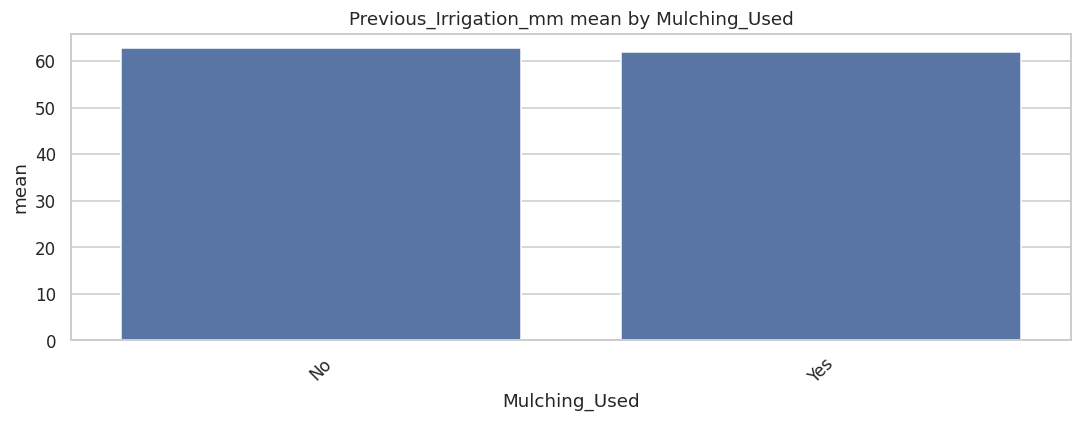

Water_Source x Rainfall_mm


,Water_Source,mean,std,median,count
0,Reservoir,1471.599352,615.784927,1487.11,162994
1,River,1458.638753,620.974028,1465.07,159819
2,Groundwater,1465.384229,604.651582,1464.45,154155
3,Rainwater,1452.731516,609.783928,1451.93,153032


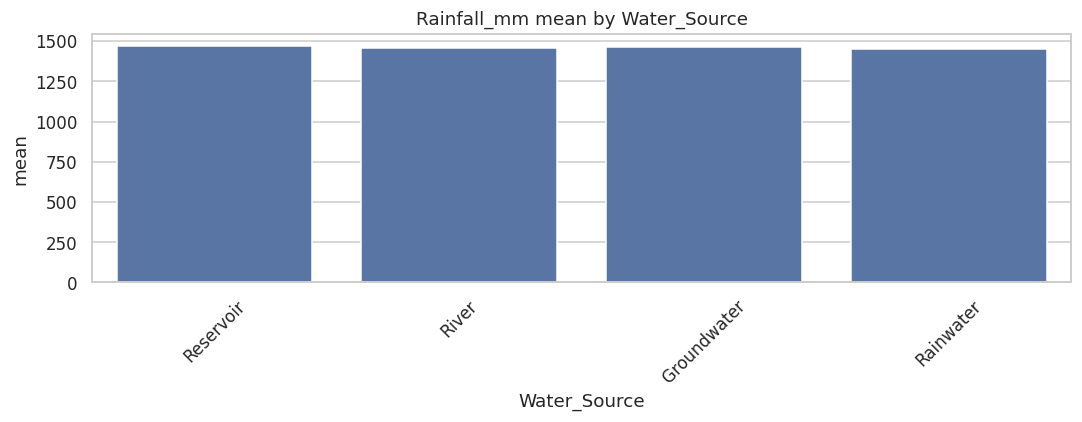

Water_Source x Soil_Moisture


,Water_Source,mean,std,median,count
0,Reservoir,37.001126,16.351722,37.35,162994
1,River,36.954614,16.556056,37.34,159819
2,Groundwater,37.711635,16.265073,38.13,154155
3,Rainwater,37.582828,16.314266,38.12,153032


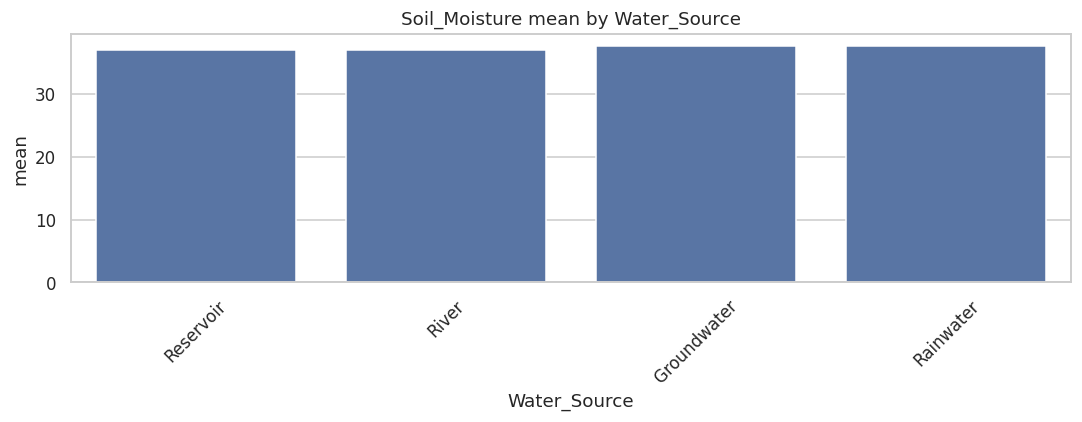

Water_Source x Temperature_C


,Water_Source,mean,std,median,count
0,Reservoir,27.019556,8.633250,26.96,162994
1,River,27.180457,8.601282,27.28,159819
2,Groundwater,26.786784,8.581833,26.71,154155
3,Rainwater,26.997942,8.673939,26.97,153032


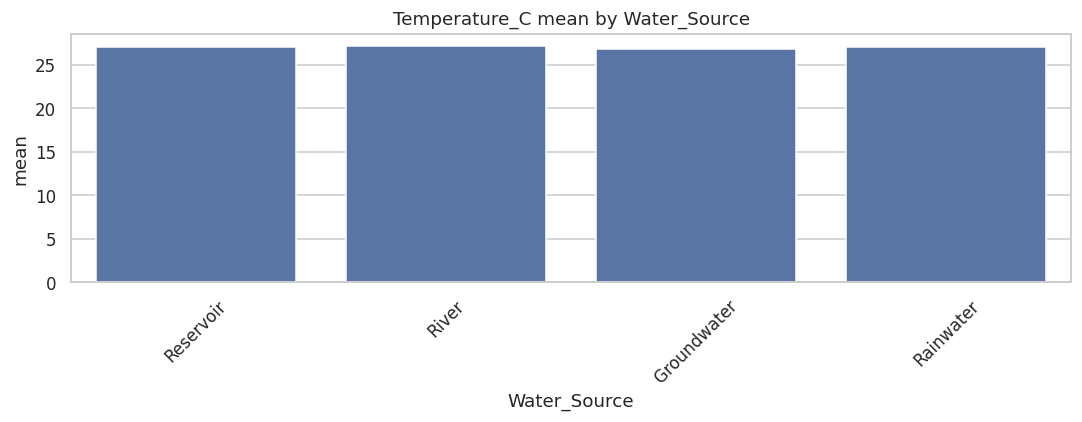

Water_Source x Wind_Speed_kmh


,Water_Source,mean,std,median,count
0,Reservoir,10.325083,5.713198,10.46,162994
1,River,10.379595,5.664355,10.52,159819
2,Groundwater,10.412665,5.692770,10.54,154155
3,Rainwater,10.387050,5.686623,10.47,153032


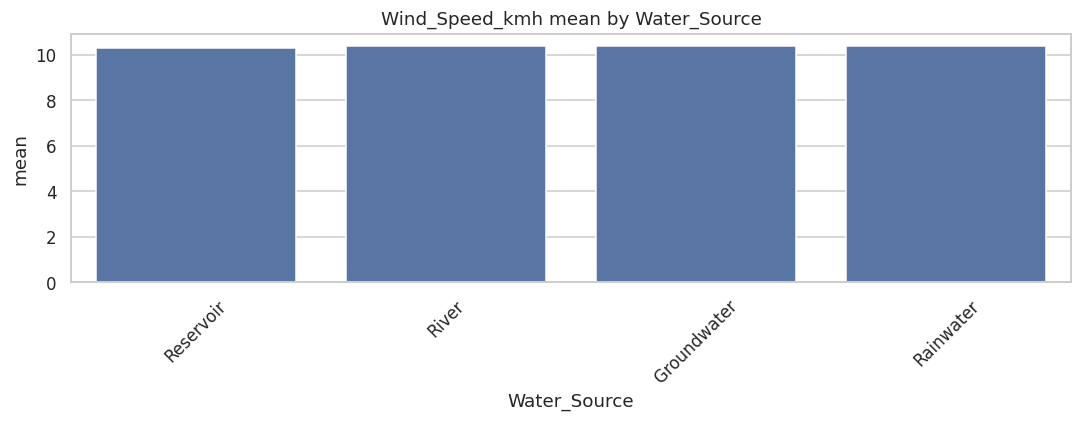

Water_Source x Previous_Irrigation_mm


,Water_Source,mean,std,median,count
0,Reservoir,62.096766,34.326638,60.61,162994
1,River,62.258284,34.171641,61.15,159819
2,Groundwater,62.688441,34.205062,61.76,154155
3,Rainwater,62.243571,34.280070,60.97,153032


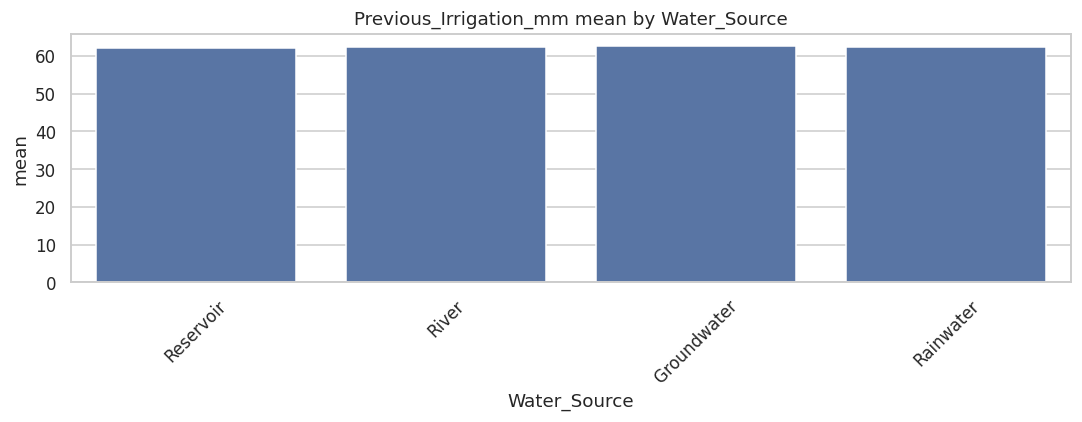

Irrigation_Type x Rainfall_mm


,Irrigation_Type,mean,std,median,count
0,Canal,1454.339453,625.838708,1461.18,161901
1,Sprinkler,1469.050326,610.226076,1479.05,161400
2,Rainfed,1455.970592,607.875659,1452.87,155607
3,Drip,1469.752314,607.071242,1480.11,151092


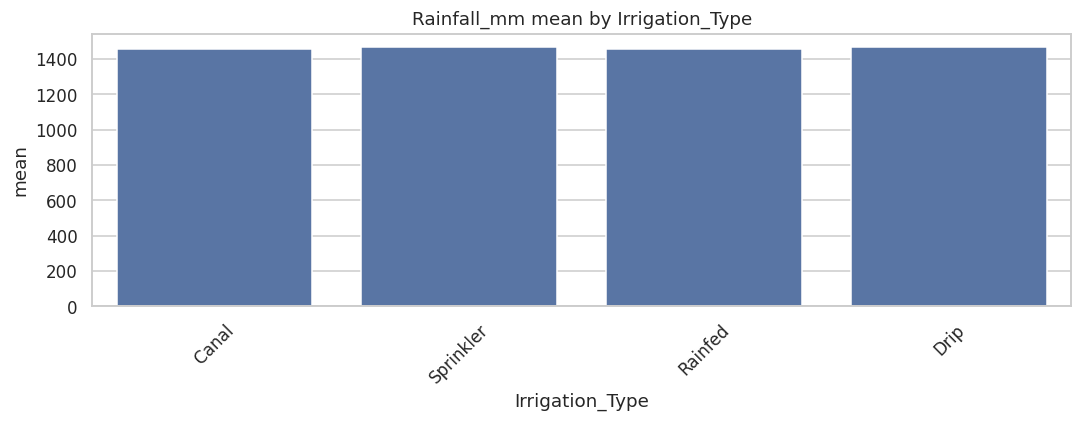

Irrigation_Type x Soil_Moisture


,Irrigation_Type,mean,std,median,count
0,Canal,36.508997,16.618181,36.80,161901
1,Sprinkler,37.282365,16.331484,37.53,161400
2,Rainfed,37.765893,16.283078,38.49,155607
3,Drip,37.705301,16.229188,38.28,151092


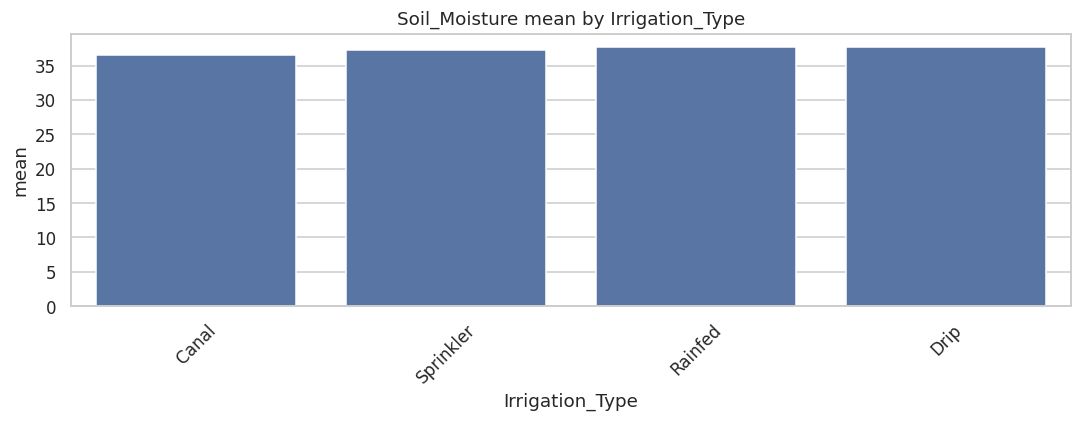

Irrigation_Type x Temperature_C


,Irrigation_Type,mean,std,median,count
0,Canal,27.044075,8.592379,27.24,161901
1,Sprinkler,27.044859,8.647028,26.97,161400
2,Rainfed,26.869628,8.629502,26.75,155607
3,Drip,27.031474,8.624709,27.01,151092


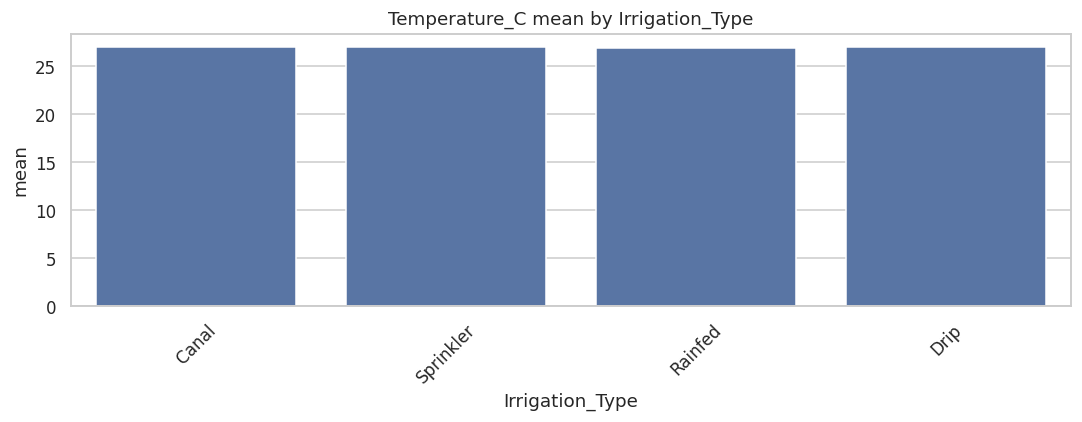

Irrigation_Type x Wind_Speed_kmh


,Irrigation_Type,mean,std,median,count
0,Canal,10.474558,5.703095,10.67,161901
1,Sprinkler,10.363213,5.661289,10.42,161400
2,Rainfed,10.362687,5.688809,10.48,155607
3,Drip,10.295236,5.704031,10.34,151092


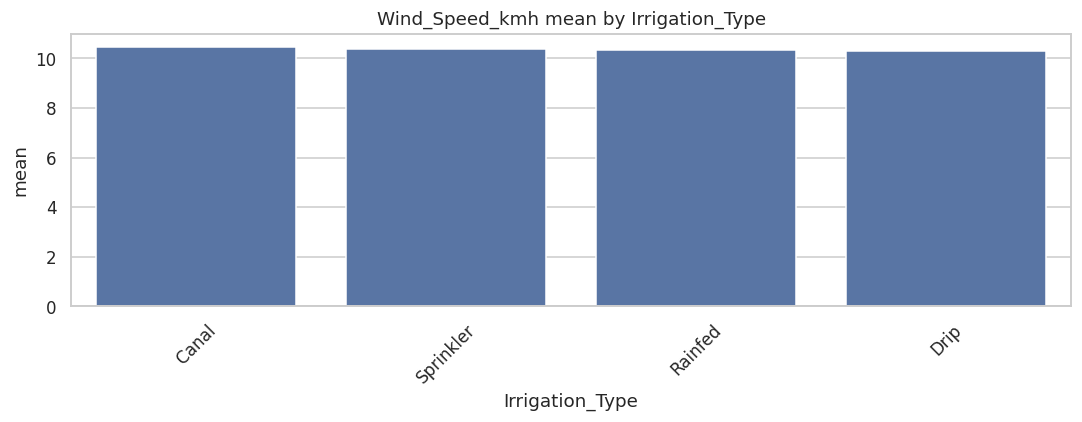

Irrigation_Type x Previous_Irrigation_mm


,Irrigation_Type,mean,std,median,count
0,Canal,63.229695,34.872275,61.780,161901
1,Sprinkler,61.991937,33.807701,61.250,161400
2,Rainfed,61.849114,34.278486,59.990,155607
3,Drip,62.173029,33.985509,60.885,151092


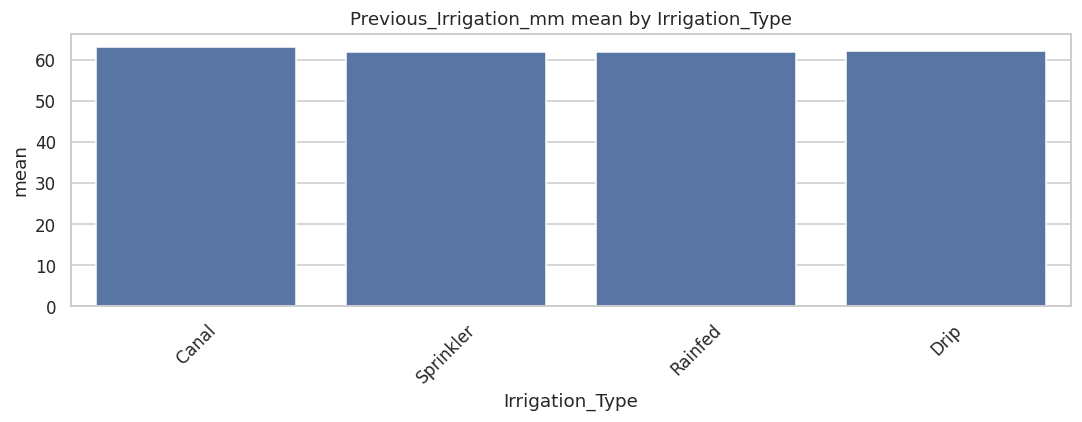


Top category-combo candidates:


,combo,te_candidate_score,nunique,min_count,median_count,max_count
2,Crop_Growth_Stage__Irrigation_Type,0.522229,16,35232,39054.0,43835
1,Crop_Growth_Stage__Water_Source,0.522016,16,35675,39214.0,43468
0,Crop_Growth_Stage__Mulching_Used,0.464569,8,67088,80179.0,86367
3,Mulching_Used__Water_Source,0.242958,8,75632,77933.5,82361
4,Mulching_Used__Irrigation_Type,0.242785,8,74419,77305.0,85677
5,Water_Source__Irrigation_Type,0.043858,16,35781,39489.5,43800



Recommended TE candidates:


,feature,te_candidate_score,nunique,min_count,median_count,max_count,decision
2,Crop_Growth_Stage,0.421264,4,147502,157404.5,167689,strong_candidate
6,Mulching_Used,0.201923,2,313547,315000.0,316453,strong_candidate
5,Water_Source,0.025540,4,153032,156987.0,162994,low_priority
4,Irrigation_Type,0.023770,4,151092,158503.5,161901,low_priority
1,Crop_Type,0.019169,6,102469,104459.5,108910,low_priority
3,Season,0.016153,3,205406,208033.0,216561,low_priority
0,Soil_Type,0.010914,4,148566,157462.5,166509,low_priority
7,Region,0.008399,5,114127,126163.0,134809,low_priority



Strong TE candidates:
['Crop_Growth_Stage', 'Mulching_Used']

Possible TE candidates:
[]

Saved:
- eda_cat_score_ranking.csv
- eda_num_summary_ranking.csv
- eda_combo_score_ranking.csv
- eda_te_recommendation.csv


In [2]:
# =========================================================
# EDA NOTEBOOK FOR FEATURE / TE CANDIDATE SELECTION
# Playground Series S6E4 - Predicting Irrigation Need
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
TARGET = "Irrigation_Need"

# =========================================================
# 1. LOAD DATA
# =========================================================
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

print("train:", train.shape)
print("test :", test.shape)

display(train.head())

# =========================================================
# 2. BASIC SETUP
# =========================================================
y_raw = train[TARGET].copy()
X = train.drop(columns=["id", TARGET]).copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("\nCategorical columns:")
print(cat_cols)

print("\nNumeric columns:")
print(num_cols)

print("\nTarget distribution:")
display(train[TARGET].value_counts())
display(train[TARGET].value_counts(normalize=True).rename("ratio"))

# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================
def plot_target_distribution():
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=train, x=TARGET)
    ax.set_title("Target Distribution")
    plt.show()


def summarize_categorical_feature(df, col, target=TARGET):
    count_df = df[col].value_counts(dropna=False).rename("count").reset_index()
    count_df.columns = [col, "count"]

    ratio_df = (
        df.groupby(col, dropna=False)[target]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
    )

    pivot_ratio = ratio_df.pivot(index=col, columns=target, values="ratio").fillna(0)
    pivot_ratio["n_samples"] = df[col].value_counts(dropna=False)

    # sort by sample size
    pivot_ratio = pivot_ratio.sort_values("n_samples", ascending=False)

    return count_df, pivot_ratio.reset_index()


def plot_categorical_target_distribution(df, col, target=TARGET, top_n=20):
    tmp = df[col].value_counts().head(top_n).index
    plot_df = df[df[col].isin(tmp)].copy()

    ratio_df = (
        plot_df.groupby(col)[target]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
    )

    pivot_ratio = ratio_df.pivot(index=col, columns=target, values="ratio").fillna(0)
    order = plot_df[col].value_counts().head(top_n).index

    pivot_ratio = pivot_ratio.loc[order]

    pivot_ratio.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )
    plt.title(f"{col} - Target Distribution (Top {top_n})")
    plt.ylabel("Ratio")
    plt.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def score_categorical_separation(df, col, target=TARGET):
    """
    Heuristic score for TE usefulness:
    - larger class distribution differences across categories
    - penalized a bit when sample counts are tiny
    """
    dist = (
        df.groupby(col)[target]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
        .pivot(index=col, columns=target, values="ratio")
        .fillna(0)
    )

    counts = df[col].value_counts()
    dist["count"] = counts

    class_cols = [c for c in dist.columns if c != "count"]

    global_dist = df[target].value_counts(normalize=True)
    for cls in global_dist.index:
        if cls not in dist.columns:
            dist[cls] = 0.0

    class_cols = list(global_dist.index)

    # weighted deviation from global target distribution
    score = 0.0
    total_n = len(df)
    for cat_value, row in dist.iterrows():
        local_n = row["count"]
        local_weight = np.sqrt(local_n / total_n)
        local_score = 0.0
        for cls in class_cols:
            local_score += abs(row[cls] - global_dist[cls])
        score += local_weight * local_score

    # cardinality penalty
    nunique = df[col].nunique(dropna=False)
    score = score / np.log2(nunique + 2)

    return score, nunique, counts.min(), counts.median(), counts.max()


def plot_numeric_by_target(df, col, target=TARGET):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.kdeplot(data=df, x=col, hue=target, common_norm=False, ax=axes[0])
    axes[0].set_title(f"{col} - KDE by Target")

    sns.boxplot(data=df, x=target, y=col, ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot by Target")

    plt.tight_layout()
    plt.show()


def plot_numeric_summary_table(df, num_cols, target=TARGET):
    rows = []
    for col in num_cols:
        stats = df.groupby(target)[col].agg(["mean", "std", "median"]).reset_index()
        row = {"feature": col}
        for _, r in stats.iterrows():
            cls = r[target]
            row[f"{cls}_mean"] = r["mean"]
            row[f"{cls}_std"] = r["std"]
            row[f"{cls}_median"] = r["median"]

        # simple separation score
        means = [row.get(f"{cls}_mean", np.nan) for cls in df[target].unique()]
        means = np.array(means, dtype=float)
        row["mean_range"] = np.nanmax(means) - np.nanmin(means)

        rows.append(row)

    summary = pd.DataFrame(rows).sort_values("mean_range", ascending=False)
    return summary


# =========================================================
# 4. TARGET DISTRIBUTION
# =========================================================
plot_target_distribution()

# =========================================================
# 5. CATEGORICAL EDA
# =========================================================
cat_scores = []

for col in cat_cols:
    score, nunique, min_count, med_count, max_count = score_categorical_separation(train, col)

    cat_scores.append({
        "feature": col,
        "te_candidate_score": score,
        "nunique": nunique,
        "min_count": min_count,
        "median_count": med_count,
        "max_count": max_count
    })

cat_score_df = pd.DataFrame(cat_scores).sort_values(
    ["te_candidate_score", "median_count"], ascending=[False, False]
)

print("\nCategorical feature ranking for TE candidates:")
display(cat_score_df)

# Visualize all original categorical features
for col in cat_cols:
    print("=" * 80)
    print(f"[Categorical] {col}")
    count_df, ratio_df = summarize_categorical_feature(train, col)

    display(count_df.head(20))
    display(ratio_df.head(20))

    plot_categorical_target_distribution(train, col, top_n=20)

# =========================================================
# 6. NUMERIC EDA
# =========================================================
num_summary_df = plot_numeric_summary_table(train, num_cols, target=TARGET)

print("\nNumeric feature summary ranking:")
display(num_summary_df)

for col in num_cols:
    print("=" * 80)
    print(f"[Numeric] {col}")
    display(train.groupby(TARGET)[col].describe().T)
    plot_numeric_by_target(train, col)

# =========================================================
# 7. CATEGORY x NUMERIC QUICK CHECK
# =========================================================
# Useful for deciding category combinations later
priority_cat_cols = cat_score_df["feature"].head(4).tolist()
priority_num_cols = num_summary_df["feature"].head(5).tolist()

print("\nPriority categorical columns:", priority_cat_cols)
print("Priority numeric columns    :", priority_num_cols)

for ccol in priority_cat_cols:
    for ncol in priority_num_cols:
        tmp = (
            train.groupby(ccol)[ncol]
            .agg(["mean", "std", "median", "count"])
            .sort_values("count", ascending=False)
            .head(15)
            .reset_index()
        )

        print("=" * 80)
        print(f"{ccol} x {ncol}")
        display(tmp)

        plt.figure(figsize=(10, 4))
        sns.barplot(data=tmp, x=ccol, y="mean")
        plt.title(f"{ncol} mean by {ccol}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# =========================================================
# 8. SIMPLE COMBO EDA FOR TOP CATEGORIES
# =========================================================
# Only for a few high-priority combos, not everything
combo_candidates = []

top_cats = priority_cat_cols[:4]
for i in range(len(top_cats)):
    for j in range(i + 1, len(top_cats)):
        c1, c2 = top_cats[i], top_cats[j]
        combo_col = f"{c1}__{c2}"
        tmp_df = train[[c1, c2, TARGET]].copy()
        tmp_df[combo_col] = tmp_df[c1].astype(str) + "__" + tmp_df[c2].astype(str)

        score, nunique, min_count, med_count, max_count = score_categorical_separation(
            tmp_df, combo_col, target=TARGET
        )

        combo_candidates.append({
            "combo": combo_col,
            "te_candidate_score": score,
            "nunique": nunique,
            "min_count": min_count,
            "median_count": med_count,
            "max_count": max_count
        })

combo_score_df = pd.DataFrame(combo_candidates).sort_values(
    ["te_candidate_score", "median_count"], ascending=[False, False]
)

print("\nTop category-combo candidates:")
display(combo_score_df)

# =========================================================
# 9. FINAL RECOMMENDATION TABLE
# =========================================================
recommended_te = cat_score_df.copy()

def te_decision(row):
    if row["te_candidate_score"] > 0.20 and row["median_count"] >= 100:
        return "strong_candidate"
    elif row["te_candidate_score"] > 0.10 and row["median_count"] >= 30:
        return "possible_candidate"
    else:
        return "low_priority"

recommended_te["decision"] = recommended_te.apply(te_decision, axis=1)

print("\nRecommended TE candidates:")
display(recommended_te)

strong_te_cols = recommended_te.loc[
    recommended_te["decision"] == "strong_candidate", "feature"
].tolist()

possible_te_cols = recommended_te.loc[
    recommended_te["decision"] == "possible_candidate", "feature"
].tolist()

print("\nStrong TE candidates:")
print(strong_te_cols)

print("\nPossible TE candidates:")
print(possible_te_cols)

# =========================================================
# 10. EXPORT SMALL SUMMARY
# =========================================================
cat_score_df.to_csv("eda_cat_score_ranking.csv", index=False)
num_summary_df.to_csv("eda_num_summary_ranking.csv", index=False)
combo_score_df.to_csv("eda_combo_score_ranking.csv", index=False)
recommended_te.to_csv("eda_te_recommendation.csv", index=False)

print("\nSaved:")
print("- eda_cat_score_ranking.csv")
print("- eda_num_summary_ranking.csv")
print("- eda_combo_score_ranking.csv")
print("- eda_te_recommendation.csv")

# カテゴリカラムについて

## Crop_Growth_Stage
### Result
* TEスコアが最大
* クラス間分布が大きい
* Harvest, SowingはLowに偏る
* Flowing, Vegatativeはmediumに偏る。

### interpretatioon
* 灌漑に対する需要側の特徴量であり、予測に効きやすいと考えられる。

## Mulching_Used
### Result
* Yes, Noの分布差が大きい
* YesはLowが増え、NoでMedium, Highが増える

### interpretation
* マルチングで蒸発散の抑制に寄与していると考えられる。

## Water_Source
### Result
* 単体だと弱そう
* Crop_Growth_stageとの組み合わせは良さそう

### interpretation
* 単体利用ではなく、組み合わせて利用する方針

## Irrigation_Type
### Result
* 単体だと弱そう
* Crop_Growth_stageとの組み合わせは良さそう

### interpretation
* 単体利用ではなく、組み合わせて利用する方針

## Crop_Type
### Result
* クラス間の分布差は見られる

### interpretation
* 必要であれば学習から除外
* TEはしなくても良い

## Season
### Result
* あまり効かなそう

### interpretation
* 気象要素そのものの方がより灌漑に対しては直接的に聞くと考えられる
* TEは不要

## > Soil_Type
### Result
* 単体だと弱そう（非常に予想外）

### interpretatin
* TEはしなくても良い

## Region
### Result
* 予測に効かなそう

### interpretation
* TEはしなくても良い

# 数値カラムについて

## Rainfall_mm
### Result
* Highの平均が低い

### interpretation
* 雨が少ないほど灌漑が必要になるという関係が読み取れ、非常に納得がいく

## Siol_Moisture
### Result
* クラス間の差が大きい
* Highが低く、Lowが高め、物理的にも納得

### interpretation
* 過去の水収支の情報も入っていそう

## Tenperture_C
### Result
* Highが低く、Lowが高め、物理的にも納得

### interpretation
* 蒸発散に関わる特徴量

## Wind_Speed_kmh
### Result
* Highが低く、Lowが高め、物理的にも納得

### interpretation
* 蒸発散の促進として効いていそう

## Previous_Irrigation_mm
### Result
* 平均はそこまで差がない
* 中央値、偏差、分布には差がみられる

### interpretation
* 水収支系に織り交ぜる

## Humidity
### Result
* クラス間の差は小さい

### interpretation
*  単体では想像より効きにくい

## Field_Area_hectare
### Result
* クラス間の差は小さい

### interpretation
* 面積そのものはあまり効かない

## Soil_pH
### Result
* クラス間の差は小さい

### interpretation
* 直接は効かない

## Electrical_Conductivity
### Result
* クラス間の差は小さい

### interpretation
*  単体より、補助的な特徴量として使う

## Sunlight_Hours
### Result
*  クラス間の差は小さい

### interpretation
* 他の特徴量とくみあわせて利用

## Organic_Carbon
### Result
* 効かなそう

# 組み合わせ特徴量

重要な特徴量
## Crop_Growth_Stage__Irrigation_Type

## Crop_Growth_Stage__Water_Source

## Crop_Growth_Stage__Mulching_Used

## Mulching_Used__Water_Source

## Mulching_Used__Irrigation_Type